In [1]:
import pandas as pd

In [2]:
metadata_tcia = pd.read_excel("data/metadata_tcia.xlsx")
metadata_ku = pd.read_json("data/metadata_ku.json", lines=True)

In [3]:
# get Patient Sex count of data
group_by_patient = metadata_tcia.groupby('Patient ID').first().reset_index()
sex_counts = group_by_patient['Patient Sex'].value_counts()
sex_counts

Patient Sex
F    401
M    353
U     19
O     12
Name: count, dtype: int64

In [4]:
# get manufacturer count
manufacturer_counts = group_by_patient['Manufacturer'].value_counts()
manufacturer_counts

Manufacturer
SIEMENS               501
GE MEDICAL SYSTEMS    227
Philips                31
TOSHIBA                26
Name: count, dtype: int64

In [5]:
# merge dataframes by 'Study Instance UID' and 'InstanceUID'
merged_data = pd.merge(metadata_tcia, metadata_ku, left_on='Series Instance UID', right_on='InstanceUID', how='inner')
# Display the first few rows of the merged data
print(merged_data.shape)
merged_data.head(2)


(1714, 61)


,Patient ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study Instance UID,Study Date,...,patients_age,slice_location,gender,new_sub_id,scan,position,mha_path,dicom_path,split,segmentation_path
0,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.9328.50.4.1,2000-01-01 00:00:00.0,...,59.0,551.9,F,sub001,1,prone,converted/sub001/sub001_pos-prone_scan-1_conv-...,raw/sub001/sub001_pos-prone_scan-1.zip,None,None
1,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.9328.50.4.1,2000-01-01 00:00:00.0,...,59.0,562.2,F,sub001,1,supine,converted/sub001/sub001_pos-supine_scan-1_conv...,raw/sub001/sub001_pos-supine_scan-1.zip,test,segmentations/segmentations-regionalgrowing-qc...


In [35]:
# check if subjects have scans form different scanners
subject_scanner_counts = merged_data.groupby('new_sub_id')['Manufacturer'].nunique()
subject_scanner_counts[subject_scanner_counts == 0]

new_sub_id
sub015    0
sub016    0
sub017    0
sub018    0
sub019    0
sub020    0
sub021    0
sub022    0
sub023    0
sub024    0
sub025    0
sub026    0
sub027    0
sub028    0
sub029    0
sub030    0
sub031    0
sub032    0
sub033    0
sub034    0
sub035    0
sub036    0
sub037    0
sub038    0
sub039    0
sub040    0
sub041    0
sub042    0
sub043    0
sub044    0
sub045    0
sub046    0
sub047    0
sub048    0
sub049    0
sub253    0
sub254    0
sub255    0
sub468    0
sub469    0
Name: Manufacturer, dtype: int64

In [58]:
annotations_daria = pd.read_csv("Annotation_Agreement 2.csv")
annotations_niclas = pd.read_csv("Annotation_Agreement 1.csv")

# remove rows with empty file names
annotations_daria = annotations_daria[annotations_daria['File / Case ID'].notna()]
annotations_niclas = annotations_niclas[annotations_niclas['File / Case ID'].notna()]

# only keep accepted or edited annotations
annotations_daria = annotations_daria[annotations_daria['5. Final\nDecision'].isin(['Accept', 'Accept with edits'])]
annotations_niclas = annotations_niclas[annotations_niclas['5. Final\nDecision'].isin(['Accept', 'Accept with edits'])]

# extract subject id from file name
annotations_daria['Subject ID'] = annotations_daria['File / Case ID'].str.extract(r'(\d{3})')
annotations_niclas['Subject ID'] = annotations_niclas['File / Case ID'].str.extract(r'(\d{3})')

# add scanner from merged_data (subxxx) to annotations (xxx)
annotations_daria['Scanner'] = annotations_daria['Subject ID'].apply(lambda x: merged_data.loc[merged_data['new_sub_id'] == f'sub{x}', 'Manufacturer'].values[0])
annotations_niclas['Scanner'] = annotations_niclas['Subject ID'].apply(lambda x: merged_data.loc[merged_data['new_sub_id'] == f'sub{x}', 'Manufacturer'].values[0])

# add age
annotations_daria['patients_age'] = annotations_daria['Subject ID'].apply(lambda x: merged_data.loc[merged_data['new_sub_id'] == f'sub{x}', 'Patient Age'].values[0])
annotations_niclas['patients_age'] = annotations_niclas['Subject ID'].apply(lambda x: merged_data.loc[merged_data['new_sub_id'] == f'sub{x}', 'Patient Age'].values[0])

# Keep only rows where 'Patient Age' is between 50 and 90
annotations_daria['patients_age'] = pd.to_numeric(annotations_daria['patients_age'].str.extract(r'(\d+)')[0], errors='coerce')
annotations_daria = annotations_daria[(annotations_daria['patients_age'] >= 50) & (annotations_daria['patients_age'] <= 90)]

annotations_niclas['patients_age'] = pd.to_numeric(annotations_niclas['patients_age'].str.extract(r'(\d+)')[0], errors='coerce')
annotations_niclas = annotations_niclas[(annotations_niclas['patients_age'] >= 50) & (annotations_niclas['patients_age'] <= 90)]

# remove rows with null values in the 'Scanner' column
annotations_daria = annotations_daria[annotations_daria['Scanner'].notnull()]
annotations_niclas = annotations_niclas[annotations_niclas['Scanner'].notnull()]

# add sex
annotations_daria['Patient Sex'] = annotations_daria['Subject ID'].apply(lambda x: merged_data.loc[merged_data['new_sub_id'] == f'sub{x}', 'Patient Sex'].values[0])
annotations_niclas['Patient Sex'] = annotations_niclas['Subject ID'].apply(lambda x: merged_data.loc[merged_data['new_sub_id'] == f'sub{x}', 'Patient Sex'].values[0])

# remove rows with sex not in ['M', 'F']
annotations_daria = annotations_daria[annotations_daria['Patient Sex'].isin(['M', 'F'])]
annotations_niclas = annotations_niclas[annotations_niclas['Patient Sex'].isin(['M', 'F'])]

# concat
combined_annotations = pd.concat([annotations_daria, annotations_niclas], ignore_index=True)

# count per scanner
scanner_counts = combined_annotations['Scanner'].value_counts()
scanner_counts

Scanner
SIEMENS               148
GE MEDICAL SYSTEMS    113
Philips                23
TOSHIBA                15
Name: count, dtype: int64

In [59]:
annotations_niclas

,File / Case ID,1. Colon\nStatus,2. FP Removal,Unnamed: 3,3. Leakage,Unnamed: 5,4. Fluid,Unnamed: 7,5. Final\nDecision,6. Effort,Notes,Subject ID,Scanner,patients_age,Patient Sex
5,402_pos-supine_colon_segmentation.mha,Very good,Yes,No,No,No,Yes,Very good,Accept with edits,Minor (<5 min),Minor removal of one false positive and tiny l...,402,TOSHIBA,54.0,M
6,403_pos-prone_colon_segmentation.mha,Very good,No,Yes,No,No,Yes,Very good,Accept with edits,Minor (<5 min),NaN,403,GE MEDICAL SYSTEMS,51.0,M
7,403_pos-supine_colon_segmentation.mha,Very good,No,Yes,Yes,Yes,Yes,Very good,Accept with edits,Major (>10 min),NaN,403,GE MEDICAL SYSTEMS,51.0,M
8,405_pos-prone_colon_segmentation.mha,Very good,No,Yes,Yes,Yes,Yes,Very good,Accept with edits,Major (>10 min),NaN,405,GE MEDICAL SYSTEMS,52.0,F
9,405_pos-supine_colon_segmentation.mha,Good,No,Yes,Yes,Yes,Yes,Good,Accept with edits,Moderate (5-10 min),NaN,405,GE MEDICAL SYSTEMS,52.0,F
10,406_pos-prone_colon_segmentation.mha,Very good,No,Yes,No,No,Yes,Very good,Accept with edits,Moderate (5-10 min),NaN,406,GE MEDICAL SYSTEMS,58.0,F
11,406_pos-supine_colon_segmentation.mha,Very good,No,Yes,Yes,Yes,Yes,Very good,Accept with edits,Moderate (5-10 min),NaN,406,GE MEDICAL SYSTEMS,58.0,F
12,407_pos-supine_colon_segmentation.mha,Good,No,Yes,Yes,Yes,Yes,Good,Accept with edits,Moderate (5-10 min),NaN,407,GE MEDICAL SYSTEMS,62.0,M
13,409_pos-prone_colon_segmentation.mha,Very good,Yes,No,Yes,Yes,Yes,Very good,Accept with edits,Moderate (5-10 min),NaN,409,GE MEDICAL SYSTEMS,51.0,M
15,411_pos-prone_colon_segmentation.mha,Very good,No,Yes,No,No,Yes,Very good,Accept with edits,Minor (<5 min),NaN,411,GE MEDICAL SYSTEMS,79.0,M


In [60]:
# randomly sample 10 rows per scanner
sampled_annotations = combined_annotations.groupby('Scanner').apply(lambda x: x.sample(n=15, random_state=42)).reset_index(drop=True)
sampled_annotations.to_csv("sampled_annotations_2.csv", index=False)

/var/folders/61/pxtt541j2rvcw2qtc24l69pc0000gp/T/ipykernel_5239/2649493995.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_annotations = combined_annotations.groupby('Scanner').apply(lambda x: x.sample(n=15, random_state=42)).reset_index(drop=True)


In [63]:
# sort by subject id
sampled_annotations.sort_values(by='Subject ID', inplace=True)
sampled_annotations

,File / Case ID,1. Colon\nStatus,2. FP Removal,Unnamed: 3,3. Leakage,Unnamed: 5,4. Fluid,Unnamed: 7,5. Final\nDecision,6. Effort,Notes,Subject ID,Scanner,patients_age,Patient Sex
17,011_pos-supine,Good,No,Yes,No,No,Yes,Good,Accept with edits,Minor (<5 min),NaN,011,Philips,56.0,M
21,012_pos-supine,Very good,Yes,Yes,Yes,Yes,Yes,Very good,Accept with edits,Minor (<5 min),NaN,012,Philips,70.0,F
1,061_pos-supine,Good,Yes,Yes,Yes,Yes,Yes,Very good,Accept with edits,Minor (<5 min),NaN,061,GE MEDICAL SYSTEMS,52.0,F
39,063_pos-supine,Very good,Yes,Yes,Yes,Yes,Yes,Very good,Accept with edits,Minor (<5 min),NaN,063,SIEMENS,66.0,F
4,070_pos-supine,Very good,No,Yes,No,No,Yes,Very good,Accept with edits,Minor (<5 min),NaN,070,GE MEDICAL SYSTEMS,62.0,M
24,072_pos-prone,Good,Yes,Yes,Yes,Yes,Yes,Good,Accept with edits,Minor (<5 min),NaN,072,Philips,57.0,F
35,075_pos-prone,Good,Yes,No,Yes,Yes,Yes,Very good,Accept with edits,Moderate (5-10 min),NaN,075,SIEMENS,60.0,F
9,077_pos-prone,Good,No,No,No,No,Yes,Good,Accept,Minor (<5 min),NaN,077,GE MEDICAL SYSTEMS,50.0,M
14,082_pos-prone,Very good,No,Yes,No,No,Yes,Very good,Accept with edits,Minor (<5 min),NaN,082,GE MEDICAL SYSTEMS,50.0,F
33,091_pos-prone,Good,Yes,Yes,No,No,Yes,Very good,Accept with edits,Moderate (5-10 min),NaN,091,SIEMENS,50.0,M


In [6]:
group_by_patient_merged = merged_data.groupby('Patient ID').first().reset_index()
manufacturer_counts = group_by_patient_merged['Manufacturer'].value_counts()
manufacturer_counts

Manufacturer
SIEMENS               501
GE MEDICAL SYSTEMS    226
Philips                31
TOSHIBA                26
Name: count, dtype: int64

In [7]:
# only keep ffs, ffp, and hfs, hfp
def filter_position(position):
    if position in ['FFS', 'FFP', 'HFS', 'HFP']:
        return position
    else:
        return None
merged_data['patient_position'] = merged_data['patient_position'].apply(filter_position)
# Drop rows with None values in 'patient_position'
merged_data = merged_data[merged_data['patient_position'].notnull()]

print(merged_data.shape)

(1666, 61)


In [8]:
# remove the ones with no Software Versions
merged_data = merged_data[merged_data['Software Versions'].notnull()]
# Print the shape of the filtered DataFrame
print(merged_data.shape)
merged_data.head(2)

(1582, 61)


,Patient ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study Instance UID,Study Date,...,patients_age,slice_location,gender,new_sub_id,scan,position,mha_path,dicom_path,split,segmentation_path
0,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.9328.50.4.1,2000-01-01 00:00:00.0,...,59.0,551.9,F,sub001,1,prone,converted/sub001/sub001_pos-prone_scan-1_conv-...,raw/sub001/sub001_pos-prone_scan-1.zip,None,None
1,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.9328.50.4.1,2000-01-01 00:00:00.0,...,59.0,562.2,F,sub001,1,supine,converted/sub001/sub001_pos-supine_scan-1_conv...,raw/sub001/sub001_pos-supine_scan-1.zip,test,segmentations/segmentations-regionalgrowing-qc...


In [9]:
# Remove rows where 'Patient Sex' is 'O'
merged_data = merged_data[(merged_data['Patient Sex'] != 'O') & (merged_data['Patient Sex'] != 'U')]

# Print the shape of the filtered DataFrame
print(merged_data.shape)

(1522, 61)


In [10]:
group_by_patient_merged = merged_data.groupby('Patient ID').first().reset_index()
manufacturer_counts = group_by_patient_merged['Manufacturer'].value_counts()
manufacturer_counts

Manufacturer
SIEMENS               471
GE MEDICAL SYSTEMS    226
Philips                30
TOSHIBA                26
Name: count, dtype: int64

In [11]:
# get sex count per manufacturer grouped by patient id
sex_counts_per_manufacturer = group_by_patient_merged.groupby('Manufacturer')['Patient Sex'].value_counts()
sex_counts_per_manufacturer

Manufacturer        Patient Sex
GE MEDICAL SYSTEMS  F              120
                    M              106
Philips             F               19
                    M               11
SIEMENS             F              244
                    M              227
TOSHIBA             F               17
                    M                9
Name: count, dtype: int64

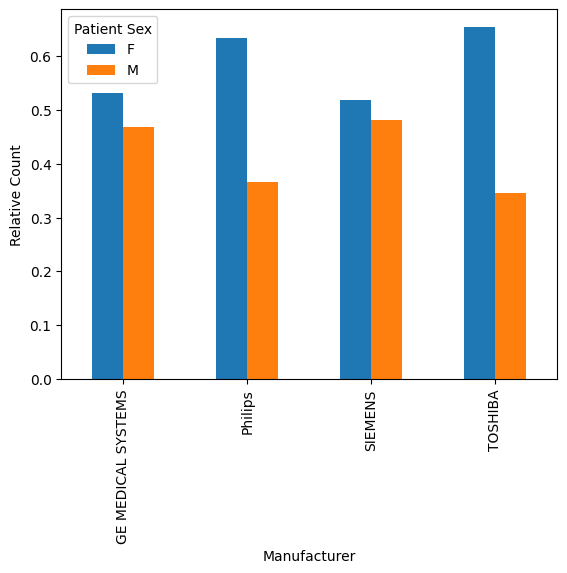

In [12]:
# plot sex relative count per manufacturer grouped by patient id
import matplotlib.pyplot as plt

relative_sex_counts_per_manufacturer = sex_counts_per_manufacturer.groupby(level=0).apply(lambda x: x / x.sum())
df_plot = relative_sex_counts_per_manufacturer.unstack()
df_plot.index = df_plot.index.get_level_values(0)
df_plot.plot(kind='bar', stacked=False)
plt.xlabel('Manufacturer')
plt.ylabel('Relative Count')

plt.show()

In [13]:
# get position count per manufacturer grouped by patient id
position_counts_per_manufacturer = merged_data.groupby('Manufacturer')['patient_position'].value_counts()
position_counts_per_manufacturer

Manufacturer        patient_position
GE MEDICAL SYSTEMS  FFS                 232
                    FFP                 227
Philips             FFS                  32
                    FFP                  29
SIEMENS             HFP                 244
                    HFS                 243
                    FFP                 237
                    FFS                 227
TOSHIBA             FFS                  26
                    FFP                  25
Name: count, dtype: int64

In [30]:
philips = merged_data[merged_data['Manufacturer'] == 'Philips']

# to csv only the columns we need
philips = philips[['new_sub_id', 'position', 'Manufacturer']]
philips.to_csv('data/philips.csv', index=False)

# philips subxxx above sub400
philips_sub400 = philips[philips['new_sub_id'].str.contains('sub[4-8][0-9][0-9]')]
philips_sub400

,new_sub_id,position,Manufacturer
1200,sub580,supine,Philips
1201,sub580,prone,Philips
1202,sub581,supine,Philips
1203,sub581,prone,Philips
1204,sub582,supine,Philips
1205,sub582,prone,Philips
1206,sub583,supine,Philips
1207,sub583,prone,Philips
1322,sub640,supine,Philips
1323,sub640,prone,Philips
